In [42]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

CONDITIONS = ['dislike', 'fist', 'like', 'ok', 'one', 'peace', 'rock', 'stop', 'three', 'two_up']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations

In [11]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'../data/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## helper function to pre-process images (color channel conversion and resizing)

In [13]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [14]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'../data/{condition}')):
        UID = filename.split('.')[0]
        img = cv2.imread(f'../data/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

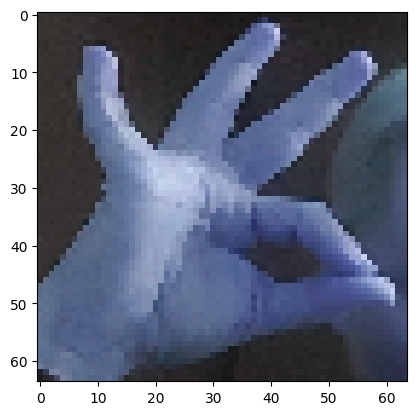

In [15]:
plt.imshow(random.sample(images, 1)[0])

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

2000
500
2000
500


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [17]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(2000, 64, 64, 3) (500, 64, 64, 3) (2000, 10) (500, 10)


In [19]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# dropout layers can drop part of the data during each epoch - this prevents overfitting
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

## Train Baseline Model from the Course

In [20]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1015 - loss: 2.3158 - val_accuracy: 0.0940 - val_loss: 2.3041 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.1090 - loss: 2.3112 - val_accuracy: 0.1460 - val_loss: 2.2951 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.1165 - loss: 2.3045 - val_accuracy: 0.2000 - val_loss: 2.2706 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.1815 - loss: 2.2364 - val_accuracy: 0.2780 - val_loss: 2.0161 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.2715 - loss: 1.9972 - val_accuracy: 0.3800 - val_loss: 1.7710 - learning_rate: 0.0010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3665 - loss: 1.7289 - val_accuracy: 0.4520 - val_loss: 1.5407 - learning_rate: 0.0010
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.4690 - los

In [21]:
# let's have a look at our model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (8, 64)                │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (8, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (8, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,208 (1.14 MB)

 Trainable params: 99,402 (388.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 198,806 (776.59 KB)

## Accuracy and loss of the training process

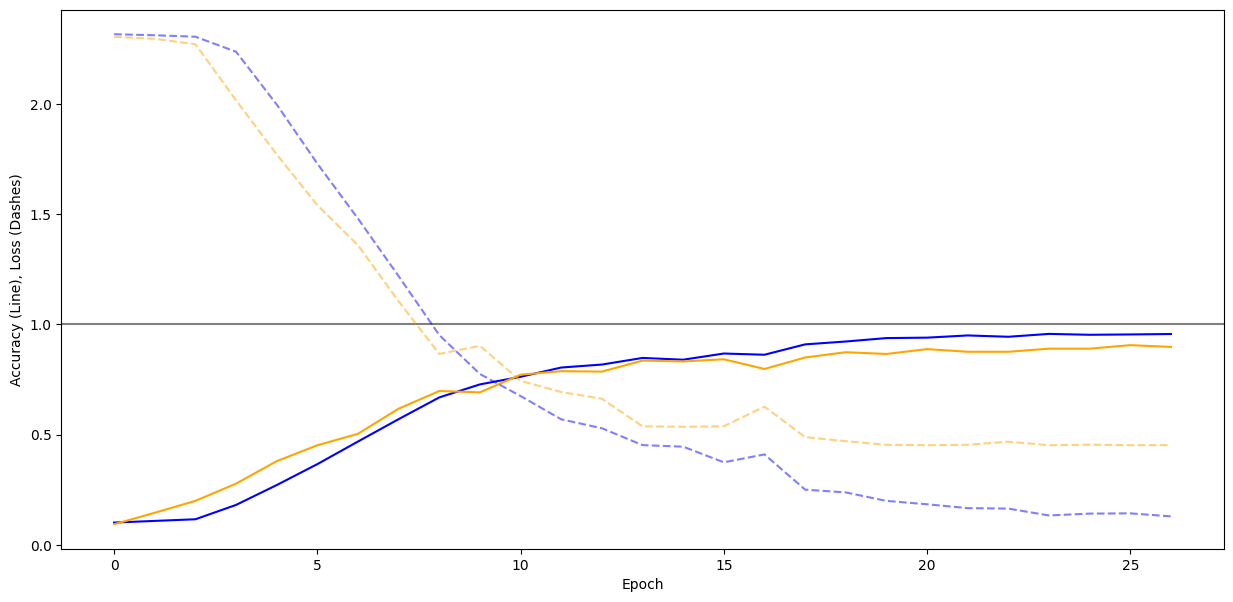

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
before [[2.6924305e-05 2.4400613e-05 1.1868293e-06 ... 4.3264589e-07
  4.4721264e-01 3.9157001e-04]
 [4.5012749e-09 8.9548848e-11 5.7454236e-06 ... 8.8923091e-13
  1.1479235e-06 9.5751171e-04]
 [1.0131198e-19 1.1022595e-19 2.3958642e-09 ... 3.3402180e-25
  1.9555038e-16 7.2541879e-03]
 ...
 [8.3890013e-25 1.6986928e-20 1.0000000e+00 ... 2.5560892e-19
  2.6258199e-15 7.5555034e-11]
 [9.9999869e-01 6.4313923e-12 1.7375526e-15 ... 8.2564801e-16
  1.2472219e-09 7.1759281e-08]
 [2.2603137e-06 3.4944076e-04 7.9981575e-05 ... 6.4454514e-05
  4.0176904e-01 8.3552331e-06]]
probabilities [8 4 4 9 6 2 6 9 1 9 1 0 3 4 2 3 5 4 1 4 8 2 8 9 0 3 5 4 5 2 5 0 4 3 3 4 7
 5 7 5 9 5 7 5 3 6 5 0 7 3 1 7 2 0 0 0 4 5 7 5 9 4 1 8 0 4 5 0 2 1 2 9 9 3
 5 4 5 9 5 0 7 1 3 0 5 7 8 1 7 7 7 2 0 3 2 5 4 6 4 0 8 4 8 7 2 4 1 7 5 2 5
 9 5 5 3 3 6 6 7 3 1 0 0 7 8 1 3 3 5 1 1 6 8 7 4 1 3 2 0 1 7 4 4 5 4 5 5 0
 2 8 1 5 2 3 3 7 7 6 0 7 5 7 2 1 0 9 3 9 8 8 8 7 2 5 3 3 3 1 7 2 6 1 1 5 4


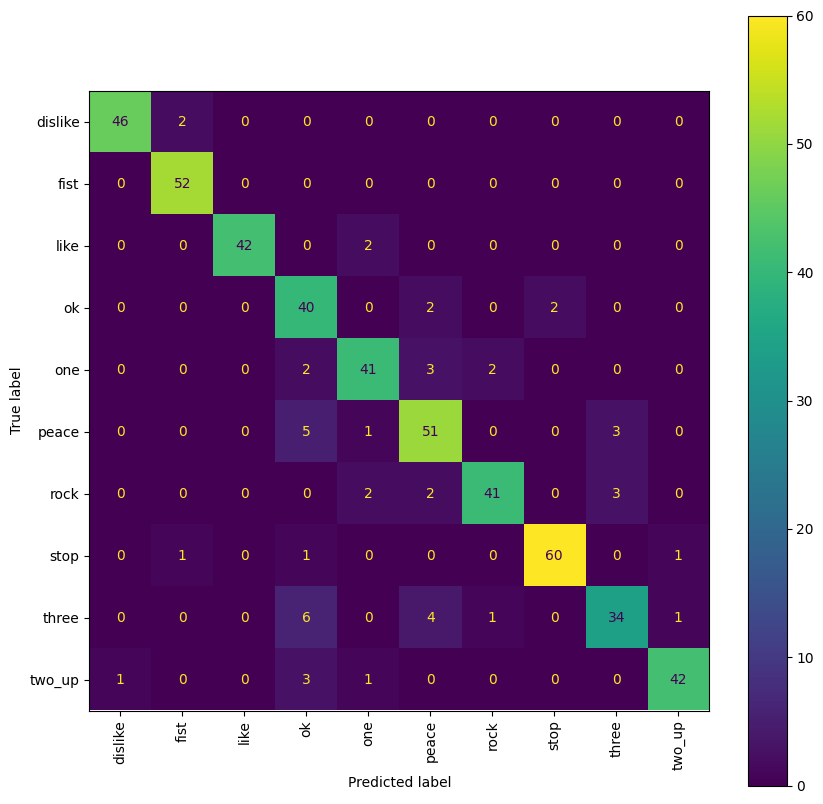

In [27]:
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

## Comparison of kernel size for the convolution Layer

### Approach & Assumptions

The original course notebook used only 2 gesture categories (`like`, `stop`). Here, all 10 available categories are used (`dislike`, `fist`, `like`, `ok`, `one`, `peace`, `rock`, `stop`, `three`, `two_up`) since a harder problem should show the effect of kernel size more clearly.

All other hyperparameters are kept fixed (`batch_size=8`, `activation_conv=leaky_relu`, `activation=relu`, `layer_count=2`, `num_neurons=64`). The kernel size is varied **uniformly across all three convolution layers** to isolate its effect.

All runs train for the same **fixed number of epochs (25)** without early stopping. Only `ReduceLROnPlateau` is kept so the learning rate can adapt equally for all runs. Without this, small kernels that converge quickly would run for 20–30 epochs while large kernels that fail to learn stop after 5, making the comparison meaningless.

**Tested values:** 3×3, 5×5, 7×7, 9×9, 11×11, 13×13

**Assumptions before training:**
- Smaller kernels (3×3, 5×5) should perform best. They are the standard choice and fit 64×64 images better, where large kernels cover too much of the image at once and lose local detail.
- Kernels of 9×9 and up should perform worse because after aggressive max-pooling the feature maps become smaller than the kernel, making the convolution meaningless.
- Inference time should increase with kernel size, since each convolution does more multiply-accumulate operations

In [ ]:
# Fixed epoch count for a fair comparison — all kernel sizes train for the same number of epochs
EXPERIMENT_EPOCHS = 25

def build_model(kernel_size):
    m = Sequential()
    m.add(RandomFlip('horizontal'))
    m.add(RandomContrast(0.1))
    m.add(Conv2D(64, kernel_size=kernel_size, activation=activation_conv, input_shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS), padding='same'))
    m.add(MaxPooling2D(pool_size=(4, 4), padding='same'))
    m.add(Conv2D(32, kernel_size=kernel_size, activation=activation_conv, padding='same'))
    m.add(MaxPooling2D(pool_size=(3, 3), padding='same'))
    m.add(Conv2D(32, kernel_size=kernel_size, activation=activation_conv, padding='same'))
    m.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    m.add(Dropout(0.2))
    m.add(Flatten())
    for _ in range(layer_count - 1):
        m.add(Dense(num_neurons, activation=activation))
    m.add(Dense(num_neurons, activation=activation))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
    return m


def train_model(model):
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    return model.fit(
        X_train, train_label,
        batch_size=batch_size,
        epochs=EXPERIMENT_EPOCHS,
        verbose=1,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr],
    )


def measure_inference_time(model, runs=5):
    """Return best-of-N inference time per image in milliseconds."""
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        model.predict(X_test, verbose=0)
        times.append(time.perf_counter() - t0)
    return (min(times) / len(X_test)) * 1000


In [51]:
kernel_sizes = [3, 5, 7, 9, 11, 13]
results = []

for ks in kernel_sizes:
    print(f"\n-- Kernel size {ks}x{ks} --")
    m = build_model(kernel_size=(ks, ks))
    hist = train_model(m)

    val_acc = max(hist.history['val_accuracy'])
    epochs_run = len(hist.history['loss'])
    inf_ms = measure_inference_time(m)

    results.append({
        'kernel_size': ks,
        'val_accuracy': val_acc,
        'epochs': epochs_run,
        'inference_ms': inf_ms,
        'history': hist.history['val_accuracy'],
    })
    print(f"  -> val_accuracy={val_acc:.3f}  epochs={epochs_run}  inference={inf_ms:.2f} ms/img")



-- Kernel size 3x3 --
Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0960 - loss: 2.3071 - val_accuracy: 0.0960 - val_loss: 2.3000 - learning_rate: 0.0010
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1640 - loss: 2.2167 - val_accuracy: 0.1780 - val_loss: 2.3467 - learning_rate: 0.0010
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3255 - loss: 1.8196 - val_accuracy: 0.4040 - val_loss: 1.6751 - learning_rate: 0.0010
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4780 - loss: 1.4561 - val_accuracy: 0.5880 - val_loss: 1.2653 - learning_rate: 0.0010
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6245 - loss: 1.0835 - val_accuracy: 0.6420 - val_loss: 0.9907 - learning_rate: 0.0010
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7095 - loss: 0.8460 - val_accuracy: 0.6940 - val_loss: 0.8601 - learning_rate: 0.0010
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accu

OSError: [Errno 22] Invalid argument: 'kernel_size_results.png'

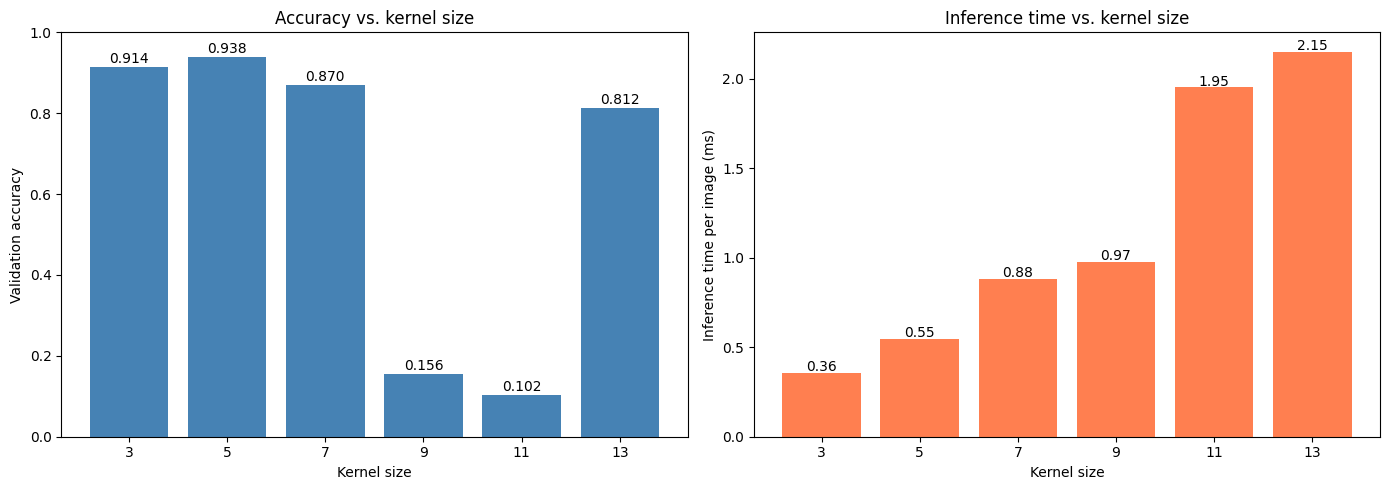

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ks_labels = [str(k) for k in kernel_sizes]

ax1.bar(ks_labels, [r['val_accuracy'] for r in results], color='steelblue')
ax1.set_xlabel('Kernel size')
ax1.set_ylabel('Validation accuracy')
ax1.set_title('Accuracy vs. kernel size')
ax1.set_ylim(0, 1)
for i, r in enumerate(results):
    ax1.text(i, r['val_accuracy'] + 0.01, f"{r['val_accuracy']:.3f}", ha='center')

ax2.bar(ks_labels, [r['inference_ms'] for r in results], color='coral')
ax2.set_xlabel('Kernel size')
ax2.set_ylabel('Inference time per image (ms)')
ax2.set_title('Inference time vs. kernel size')
for i, r in enumerate(results):
    ax2.text(i, r['inference_ms'] + 0.01, f"{r['inference_ms']:.2f}", ha='center')

plt.tight_layout()
plt.savefig('kernel_size_results.png', dpi=150)
plt.show()

print(f"\n{'Kernel':>8}  {'Val acc':>8}  {'Epochs':>7}  {'ms/img':>8}")
for r in results:
    print(f"{str(r['kernel_size']):>8}  {r['val_accuracy']:>8.3f}  {r['epochs']:>7}  {r['inference_ms']:>8.2f}")

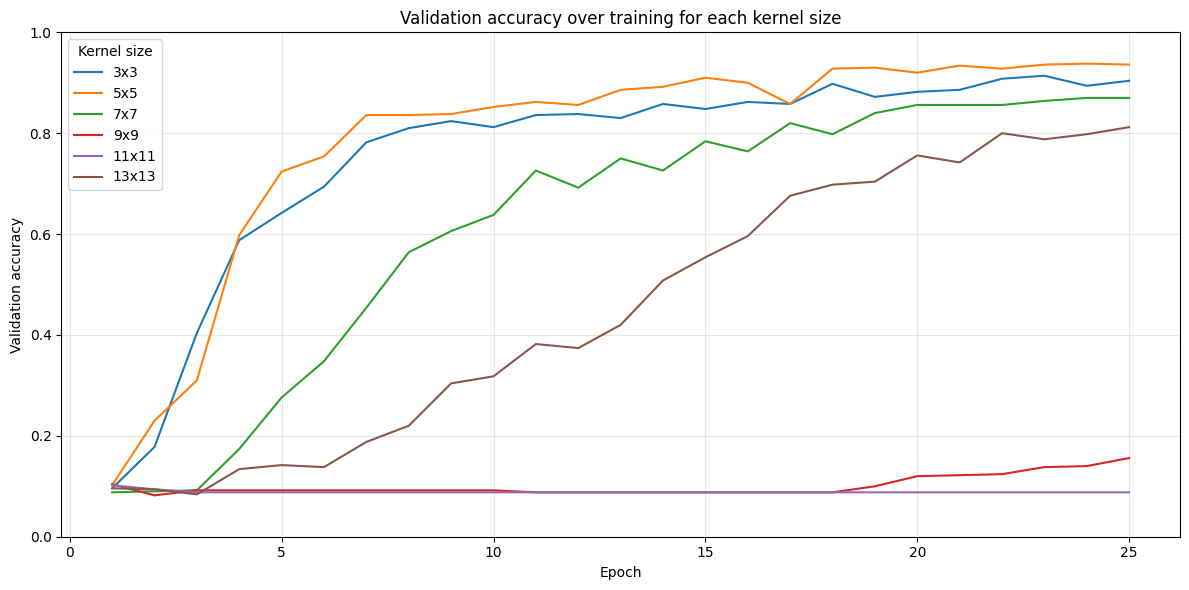

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

for r in results:
    ax.plot(range(1, len(r['history']) + 1), r['history'], label=f"{r['kernel_size']}x{r['kernel_size']}")

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.set_title('Validation accuracy over training for each kernel size')
ax.set_ylim(0, 1)
ax.legend(title='Kernel size')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kernel_size_accuracy_curves.png', dpi=150)
plt.show()


### Findings & Discussion


